In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.efficientnet_v2 import EfficientNetV2B0, preprocess_input
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator


2026-01-06 22:28:51.849469: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767738532.048255      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767738532.105513      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# 1. Load Dataset with CLAHE

data_dir = '/kaggle/input/iq-othnccd-lung-cancer-dataset-augmented/Augmented IQ-OTHNCCD lung cancer dataset'
categories = ['Benign cases', 'Malignant cases', 'Normal cases']
num_classes = len(categories)

def load_images(data_dir, img_size=224):
    X, y = [], []
    for cls in categories:
        cls_folder = os.path.join(data_dir, cls)
        for img_file in os.listdir(cls_folder):
            img_path = os.path.join(cls_folder, img_file)
            img = cv2.imread(img_path)
            if img is None:
                continue

            # --- Convert to grayscale and apply CLAHE 
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
            enhanced = clahe.apply(gray)

            # --- Back to 3 channels (EfficientNet expects 3-channel input) ---
            img = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)

            # Resize + preprocess for EfficientNetV2B0
            img = cv2.resize(img, (img_size, img_size))
            img = preprocess_input(img)

            X.append(img)
            y.append(cls)

    X = np.array(X, dtype="float32")
    y = LabelEncoder().fit_transform(y)
    y = to_categorical(y, num_classes=num_classes)
    return X, y

X, y = load_images(data_dir)

In [3]:
# Split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)
# 2. Class Weights

y_integers = np.argmax(y_train, axis=1)
class_weights = compute_class_weight('balanced', classes=np.unique(y_integers), y=y_integers)
class_weights = dict(enumerate(class_weights))


# 3. Data Augmentation

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    shear_range=0.1,
    brightness_range=[0.8, 1.2]
)
datagen.fit(X_train)



In [4]:
# 4. Build EfficientNetV2B0 Model

base_model = EfficientNetV2B0(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False  # Phase 1: Freeze

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(512, activation="relu"),
    layers.Dense(256, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


# 5. Train Phase 1

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=100,
    class_weight=class_weights,
)


I0000 00:00:1767738571.021256      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100


I0000 00:00:1767738594.398081      61 service.cc:148] XLA service 0x7915dc002f30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767738594.398973      61 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1767738596.424805      61 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/79 ━━━━━━━━━━━━━━━━━━━━ 39:52 31s/step - accuracy: 0.2500 - loss: 1.1952

I0000 00:00:1767738606.957503      61 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


79/79 ━━━━━━━━━━━━━━━━━━━━ 79s 622ms/step - accuracy: 0.6065 - loss: 4.0116 - val_accuracy: 0.7542 - val_loss: 0.7375
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 27s 340ms/step - accuracy: 0.7908 - loss: 0.5992 - val_accuracy: 0.8078 - val_loss: 0.4420
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 27s 340ms/step - accuracy: 0.8358 - loss: 0.4460 - val_accuracy: 0.8262 - val_loss: 0.3940
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 27s 344ms/step - accuracy: 0.8502 - loss: 0.3968 - val_accuracy: 0.8355 - val_loss: 0.3693
Epoch 5/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 27s 347ms/step - accuracy: 0.8303 - loss: 0.4310 - val_accuracy: 0.8133 - val_loss: 0.4240
Epoch 6/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 28s 350ms/step - accuracy: 0.8896 - loss: 0.2717 - val_accuracy: 0.8632 - val_loss: 0.3589
Epoch 7/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 28s 355ms/step - accuracy: 0.8859 - loss: 0.2601 - val_accuracy: 0.9002 - val_loss: 0.2148
Epoch 8/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 27s 343ms/step - accuracy: 0.8956 - loss: 0.2661 - val_accuracy

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9719 - loss: 0.0888
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.9964 - loss: 0.0138
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9872 - loss: 0.0323
Train Accuracy: 99.49%
Validation Accuracy: 96.86%
Test Accuracy: 98.71%
17/17 ━━━━━━━━━━━━━━━━━━━━ 13s 442ms/step
Classification Report:

                 precision    recall  f1-score   support

   Benign cases       0.97      0.99      0.98       180
Malignant cases       1.00      1.00      1.00       180
   Normal cases       0.99      0.97      0.98       182

       accuracy                           0.99       542
      macro avg       0.99      0.99      0.99       542
   weighted avg       0.99      0.99      0.99       542



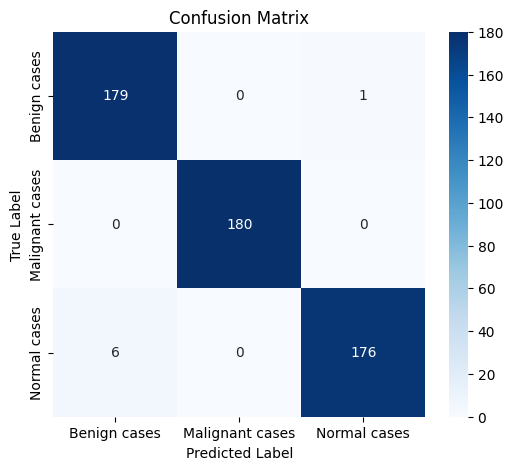

In [5]:

# 7. Evaluation

val_loss, val_acc = model.evaluate(X_val, y_val)
train_loss, train_acc = model.evaluate(X_train, y_train)
test_loss, test_acc = model.evaluate(X_test, y_test)

print(f"Train Accuracy: {train_acc*100:.2f}%")
print(f"Validation Accuracy: {val_acc*100:.2f}%")
print(f"Test Accuracy: {test_acc*100:.2f}%")


# 8. Classification Report & Confusion Matrix

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Classification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=categories))

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=categories,
            yticklabels=categories)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

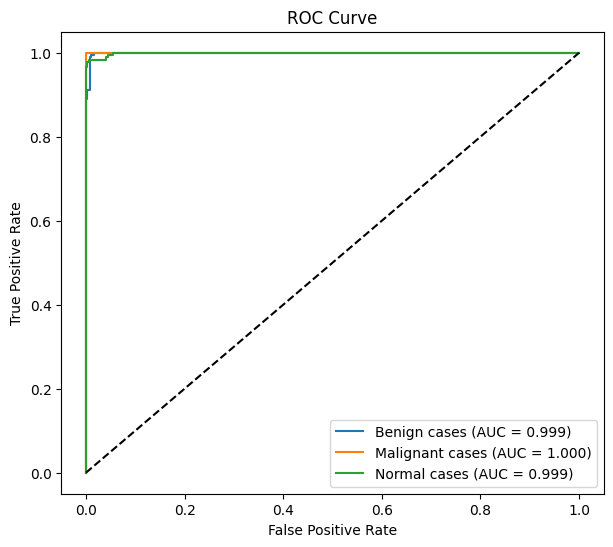

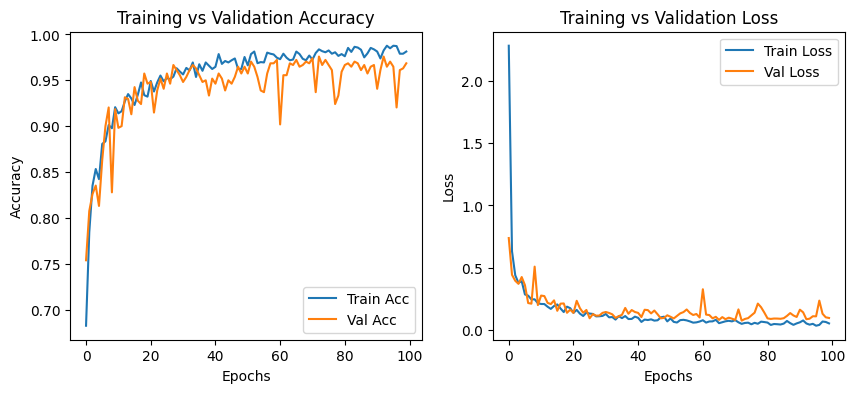

In [6]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
# 8. ROC Curve (AUC Visualization)

plt.figure(figsize=(7,6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{categories[i]} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()


# 9. Training vs Validation Graphs

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [7]:
from sklearn.model_selection import StratifiedKFold
y_labels = np.argmax(y, axis=1)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_no = 1
acc_per_fold = []
loss_per_fold = []

for train_idx, val_idx in kfold.split(X, y_labels):

    print(f"\n========== Fold {fold_no} ==========")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # Class weights per fold
    y_integers = np.argmax(y_train, axis=1)
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_integers),
        y=y_integers
    )
    class_weights = dict(enumerate(class_weights))

    # Data Augmentation
    datagen.fit(X_train)

    # Build model
    base_model = EfficientNetV2B0(
        weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)
    )
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.Flatten(),
        layers.Dense(512, activation="relu"),
        layers.Dense(256, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Train
    history = model.fit(
        datagen.flow(X_train, y_train, batch_size=32),
        validation_data=(X_val, y_val),
        epochs=50,
        class_weight=class_weights,
        verbose=1
    )

    # Evaluate
    scores = model.evaluate(X_val, y_val, verbose=0)
    print(f"Fold {fold_no} Validation Accuracy: {scores[1]*100:.2f}%")

    acc_per_fold.append(scores[1])
    loss_per_fold.append(scores[0])

    fold_no += 1
print("\n===== Cross-Validation Results =====")
print(f"Mean Accuracy: {np.mean(acc_per_fold)*100:.2f}%")
print(f"Std Accuracy:  {np.std(acc_per_fold)*100:.2f}%")



========== Fold 1 ==========


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 80s 582ms/step - accuracy: 0.6037 - loss: 3.7157 - val_accuracy: 0.7368 - val_loss: 0.7065
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 31s 343ms/step - accuracy: 0.8020 - loss: 0.5123 - val_accuracy: 0.8560 - val_loss: 0.3081
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 31s 344ms/step - accuracy: 0.8419 - loss: 0.3741 - val_accuracy: 0.9155 - val_loss: 0.2321
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 31s 343ms/step - accuracy: 0.8671 - loss: 0.3296 - val_accuracy: 0.8947 - val_loss: 0.2419
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 31s 342ms/step - accuracy: 0.8804 - loss: 0.2896 - val_accuracy: 0.8269 - val_loss: 0.4464
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 31s 344ms/step - accuracy: 0.8716 - loss: 0.3205 - val_accuracy: 0.8518 - val_loss: 0.3362
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 32s 351ms/step - accuracy: 0.8872 - loss: 0.2718 - val_accuracy: 0.9335 - val_loss: 0.1818
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 31s 344ms/step - accuracy: 0.8988 - loss: 0.2381 - val_accu

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 75s 533ms/step - accuracy: 0.5779 - loss: 4.4177 - val_accuracy: 0.7452 - val_loss: 0.8672
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 31s 341ms/step - accuracy: 0.7839 - loss: 0.5782 - val_accuracy: 0.8490 - val_loss: 0.3417
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 31s 340ms/step - accuracy: 0.8604 - loss: 0.3641 - val_accuracy: 0.8698 - val_loss: 0.2905
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 31s 344ms/step - accuracy: 0.8579 - loss: 0.3504 - val_accuracy: 0.9100 - val_loss: 0.2119
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 31s 345ms/step - accuracy: 0.8865 - loss: 0.2820 - val_accuracy: 0.8296 - val_loss: 0.4029
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 31s 342ms/step - accuracy: 0.8544 - loss: 0.3414 - val_accuracy: 0.9072 - val_loss: 0.2512
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 31s 343ms/step - accuracy: 0.8881 - loss: 0.2616 - val_accuracy: 0.9072 - val_loss: 0.2016
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 32s 346ms/step - accuracy: 0.9061 - loss: 0.2584 - val_accu

...

Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 75s 547ms/step - accuracy: 0.5932 - loss: 4.4573 - val_accuracy: 0.8172 - val_loss: 0.4209
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 31s 342ms/step - accuracy: 0.7917 - loss: 0.5835 - val_accuracy: 0.7770 - val_loss: 0.7261
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 31s 344ms/step - accuracy: 0.8174 - loss: 0.5025 - val_accuracy: 0.9003 - val_loss: 0.2611
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 32s 346ms/step - accuracy: 0.8695 - loss: 0.3223 - val_accuracy: 0.7659 - val_loss: 0.7597
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 31s 342ms/step - accuracy: 0.8729 - loss: 0.3235 - val_accuracy: 0.8975 - val_loss: 0.2363
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 31s 341ms/step - accuracy: 0.8821 - loss: 0.2830 - val_accuracy: 0.8587 - val_loss: 0.3213
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 31s 343ms/step - accuracy: 0.8740 - loss: 0.3191 - val_accuracy: 0.9211 - val_loss: 0.2080
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 32s 349ms/step - accuracy: 0.9077 - loss: 0.2320 - val_accu

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 75s 533ms/step - accuracy: 0.6163 - loss: 3.9916 - val_accuracy: 0.8199 - val_loss: 0.4600
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 31s 340ms/step - accuracy: 0.7912 - loss: 0.5535 - val_accuracy: 0.8850 - val_loss: 0.2965
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 31s 339ms/step - accuracy: 0.8193 - loss: 0.4291 - val_accuracy: 0.8934 - val_loss: 0.2763
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 31s 340ms/step - accuracy: 0.8566 - loss: 0.3414 - val_accuracy: 0.8089 - val_loss: 0.3888
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 31s 336ms/step - accuracy: 0.8813 - loss: 0.3033 - val_accuracy: 0.8255 - val_loss: 0.4682
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 31s 343ms/step - accuracy: 0.8968 - loss: 0.2681 - val_accuracy: 0.8906 - val_loss: 0.2781
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 31s 339ms/step - accuracy: 0.8805 - loss: 0.3140 - val_accuracy: 0.9030 - val_loss: 0.2584
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 31s 339ms/step - accuracy: 0.8919 - loss: 0.2755 - val_accu

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 81s 582ms/step - accuracy: 0.5849 - loss: 6.9339 - val_accuracy: 0.8280 - val_loss: 0.3930
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 31s 344ms/step - accuracy: 0.8043 - loss: 0.5005 - val_accuracy: 0.8682 - val_loss: 0.3353
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 32s 346ms/step - accuracy: 0.8433 - loss: 0.3688 - val_accuracy: 0.8086 - val_loss: 0.4449
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 32s 348ms/step - accuracy: 0.8767 - loss: 0.3053 - val_accuracy: 0.8613 - val_loss: 0.3208
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 32s 350ms/step - accuracy: 0.8509 - loss: 0.3481 - val_accuracy: 0.9043 - val_loss: 0.2483
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 32s 352ms/step - accuracy: 0.8855 - loss: 0.2951 - val_accuracy: 0.8890 - val_loss: 0.2927
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 32s 351ms/step - accuracy: 0.8734 - loss: 0.3058 - val_accuracy: 0.8988 - val_loss: 0.2602
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 32s 353ms/step - accuracy: 0.8976 - loss: 0.2261 - val_accu

In [8]:
from tensorflow.keras import Model, Input

inputs = Input(shape=(224, 224, 3))

base_model = EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_tensor=inputs
)
base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dense(256, activation="relu")(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = Model(inputs, outputs)


In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [10]:
def gradcam_efficientnet(model, img_array, class_index=None):

    # Last conv layer (EfficientNetV2)
    last_conv_layer = model.get_layer("top_conv")

    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if class_index is None:
            class_index = tf.argmax(predictions[0])
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8

    return heatmap.numpy()


In [11]:
def overlay_gradcam(img, heatmap, alpha=0.4):
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)

    colormap = plt.cm.jet
    colored_heatmap = colormap(heatmap)
    colored_heatmap = np.uint8(colored_heatmap[:, :, :3] * 255)

    return cv2.addWeighted(img, 1-alpha, colored_heatmap, alpha, 0)


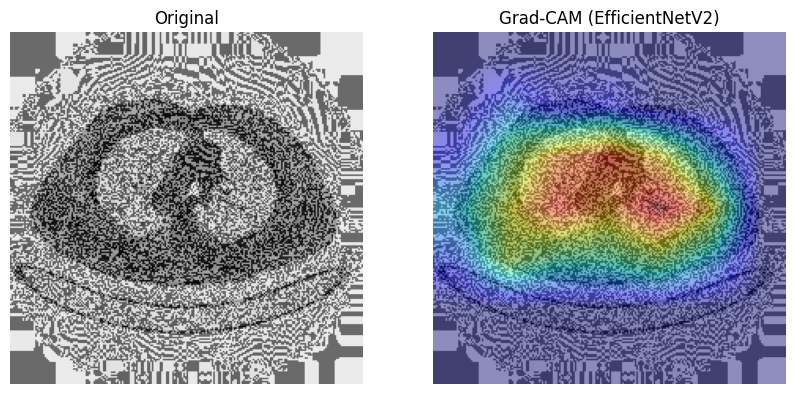

In [12]:
idx = 10
test_img = X_test[idx]
input_img = np.expand_dims(test_img, axis=0)

original_img = ((test_img + 1) * 127.5).astype(np.uint8)

heatmap = gradcam_efficientnet(model, input_img)
overlay_img = overlay_gradcam(original_img, heatmap)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(original_img)
plt.axis("off")
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(overlay_img)
plt.axis("off")
plt.title("Grad-CAM (EfficientNetV2)")
plt.show()


In [13]:
true_class = categories[np.argmax(y_test[idx])]
print("True Label:", true_class)
pred = model.predict(np.expand_dims(test_img, axis=0))
pred_class = categories[np.argmax(pred)]
confidence = np.max(pred) * 100

print("Predicted Label:", pred_class)
print(f"Confidence: {confidence:.2f}%")


True Label: Benign cases
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
Predicted Label: Benign cases
Confidence: 48.16%


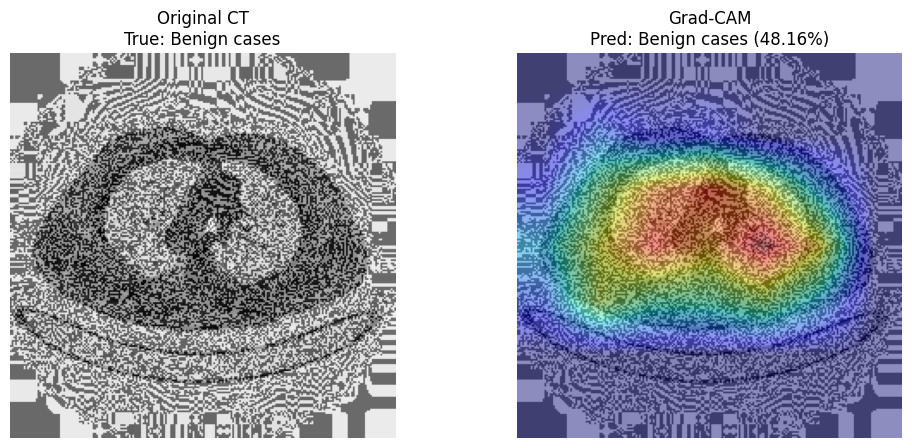

In [14]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(original_img)
plt.axis("off")
plt.title(f"Original CT\nTrue: {true_class}")

plt.subplot(1,2,2)
plt.imshow(overlay_img)
plt.axis("off")
plt.title(f"Grad-CAM\nPred: {pred_class} ({confidence:.2f}%)")

plt.show()


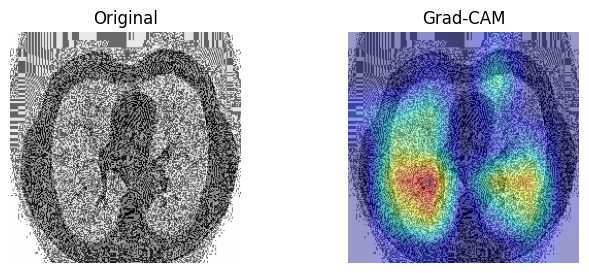

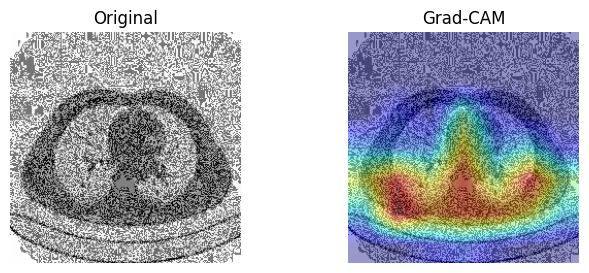

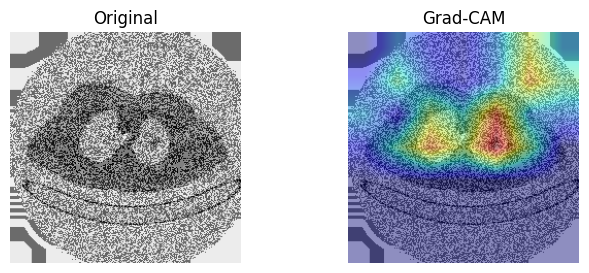

In [15]:
for i in range(3):
    img = X_test[i]
    input_img = np.expand_dims(img, axis=0)

    heatmap = gradcam_efficientnet(model, input_img)
    original_img = ((img + 1) * 127.5).astype(np.uint8)
    overlay_img = overlay_gradcam(original_img, heatmap)

    plt.figure(figsize=(8,3))
    plt.subplot(1,2,1)
    plt.imshow(original_img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(overlay_img)
    plt.title("Grad-CAM")
    plt.axis("off")
    plt.show()
